In [2]:
from agnpy.emission_regions import Cone
import astropy.units as u
from agnpy.spectra import ParticleDistribution
from agnpy.utils.conversion import nu_to_epsilon_prime, B_to_cgs, lambda_c_e, mec2
from agnpy.spectra.spectra import ExpCutoffPowerLaw
from agnpy.synchrotron import *
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid
from agnpy.synchrotron.base_synchrotron import Synchrotron
from agnpy.spectra import PowerLaw
from agnpy.spectra import LogParabola, BrokenPowerLaw
from astropy.table import Table
from astropy.coordinates import Distance
import numpy as np
from astropy.constants import c, sigma_T, m_e, e, mu0
#e = e.gauss
mec2 = mec2.to('eV')
import matplotlib.pyplot as plt
h = h.cgs

*Parameters used in Potter and Cotter to fit the BL Lac (Table 1)*

In [3]:
# Parameters used in Table 1 of Potter and Cotter; Fitting BL Lac (abdo et al. 2011)
z=0.0686
B_o =  (3.63 * 1e-5 * u.T).to(u.G)
R_o = 7.32 * 1e15 * u.cm
W_j = 7.63 * 1e36* u.W
L = R_o
theta_open = 0 * u.deg
Gamma = 12
theta_s = 2 * u.deg
A_equi = 1.0
# Electron Distribution imposed by Potter and Cotter
p = 2
gamma_minimum = 1*(5.11 * 1e6 * u.eV / mec2.to("eV")).value
gamma_c = (5.6 * 1e9 * u.eV / mec2.to("eV")).value
n_e = ExpCutoffPowerLaw(k = 996.99213 , mass=m_e, p=p, gamma_min = gamma_minimum, gamma_max= 100*gamma_c, gamma_c= gamma_c )


In [4]:
jet = Cone(R_o = R_o , B_o = B_o, L = 2*R_o, n_e = n_e, theta = theta_open, Gamma=Gamma,x_size=100,gamma_e_size=1000, z =z,delta_D=20.39,electron_escape = False)
# define the emission region and the radiative process
blob = Blob(R_b = R_o, z=z, delta_D=20.39, Gamma=12, B = B_o, n_e=n_e)

# Test 1
A conical (~cylindrical) jet with 0 degree opening angle and length with ~ 2R_blob, Radius ~ R_blob
B_blob = B_cone @ base

In [61]:
print(f' The total volume of the Cone is {jet.V_c}, which holds {np.trapz(np.trapz(jet.N_e_xg,jet.gamma_e),jet.x)} electrons')
print(f' The total volume of the Blob is {blob.V_b}, which holds {jet.norm_equi*blob.V_b*np.trapz(n_e(blob.gamma_e),blob.gamma_e)} electrons')

 The total volume of the Cone is 2.46441084631303e+48 cm3, which holds 2.399739036756726e+50 electrons
 The total volume of the Blob is 1.6429405642086868e+48 cm3, which holds 1.6296794081452317e+50 cm3 electrons


In [63]:
nu_obs = np.logspace(5, 25, 1000) * u.Hz
syn_cone= Synchrotron(jet)
flux = syn_cone.flux_obs(nu_obs)
syn_cone.evaluate_attenuation()
sed_nossa= syn_cone.sed_flux(nu_obs, ssa=False)
sed_ssa= syn_cone.sed_flux(nu_obs, ssa=True)
sed_x_nossa = syn_cone.sed_spatial(nu_obs) 
sed_x_ssa = syn_cone.sed_spatial(nu_obs,ssa=True)

/opt/anaconda3/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: overflow encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/usharma/Documents/GitHub/agnpy/agnpy/synchrotron/synchrotron_cone.py:36: RuntimeWarning: divide by zero encountered in divide
  u = 0.5 + np.exp(-tau) / tau - (1 - np.exp(-tau)) / np.power(tau, 2)
/Users/usharma/Documents/GitHub/agnpy/agnpy/synchrotron/synchrotron_cone.py:36: RuntimeWarning: overflow encountered in divide
  u = 0.5 + np.exp(-tau) / tau - (1 - np.exp(-tau)) / np.power(tau, 2)
/User

In [64]:
from agnpy.spectra import PowerLaw
from astropy.coordinates import Distance
# set the quantities defining the blob
syn_blob= Synchrotron(blob, ssa=False)
sed = syn_blob.sed_flux(nu_obs)

[[3.43840275e-05 3.60061566e-05 3.77048125e-05 ... 3.13557148e+15
  3.28349777e+15 3.43840275e+15]
 [3.05989004e-05 3.20424592e-05 3.35541205e-05 ... 2.79039561e+15
  2.92203760e+15 3.05989004e+15]
 [2.72304547e-05 2.85151010e-05 2.98603527e-05 ... 2.48321803e+15
  2.60036836e+15 2.72304547e+15]
 ...
 [3.61513353e-15 3.78568403e-15 3.96428057e-15 ... 3.29673701e+05
  3.45226658e+05 3.61513353e+05]
 [3.21716561e-15 3.36894125e-15 3.52787718e-15 ... 2.93381941e+05
  3.07222768e+05 3.21716561e+05]
 [2.86300754e-15 2.99807513e-15 3.13951478e-15 ... 2.61085319e+05
  2.73402494e+05 2.86300754e+05]]


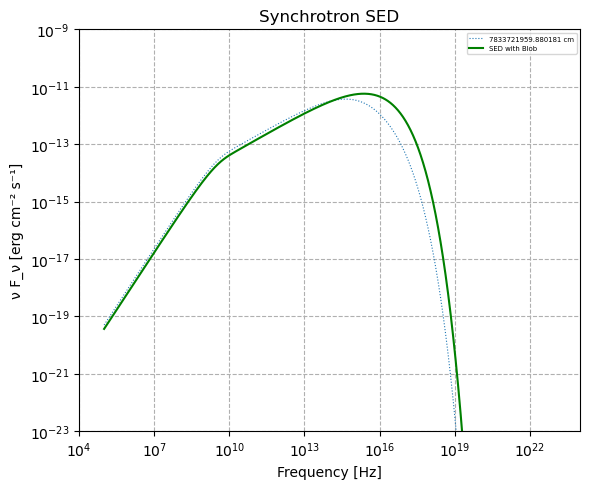

In [65]:
# Plot SED
plt.figure(figsize=(6,5))
plt.loglog(nu_obs, sed_nossa, linestyle='dotted',lw=0.8,label = jet.x[5])
plt.loglog(nu_obs, jet.norm_equi*sed, color='green', label='SED with Blob')
plt.xlabel("Frequency [Hz]")
plt.ylabel("ν F_ν [erg cm⁻² s⁻¹]")
plt.title("Synchrotron SED")
plt.grid(True, which='both', ls='--')
plt.ylim(1e-23, 1e-9)
plt.xlim(1e4,1e24)
plt.legend(fontsize=5)
plt.tight_layout()
plt.show()

Result interpretation:
- Qualitatively similar SED's, the difference can be attributed to the movement of electrons across bins.

# Validations against Literature
- Andrea 2009, Table 4 ( https://www.aanda.org/articles/aa/pdf/2009/27/aa10865-08.pdf )
- Mrk 421( https://agnpy.readthedocs.io/en/latest/tutorials/ssc_gammapy_fit.html / https://www.aanda.org/articles/aa/pdf/2022/04/aa42000-21.pdf )

# agnpy BL Lac
https://agnpy.readthedocs.io/en/latest/tutorials/ssc_gammapy_fit.html

In [ ]:
#setting the radius using the variability timescale
R_o = c.cgs*15*((1 * u.d).to("s"))/(1.0308)

<Quantity 3.76921833e+16 cm>

In [72]:
jet_1 = Cone(R_o = R_o  , B_o = 0.05 * u.G, L = 2*R_o, n_e = n_e, theta = 0*u.deg, A_equi = 1,x_size=100,gamma_e_size=1000, z =0.0308,delta_D=18,electron_escape =False)

In [73]:
nu_obs = np.logspace(5, 25, 1000) * u.Hz
syn_cone_1= Synchrotron(jet_1)
flux_1 = syn_cone_1.flux_obs(nu_obs)
syn_cone_1.evaluate_attenuation()
sed_nossa_1= syn_cone_1.sed_flux(nu_obs, ssa=False)
sed_ssa_1= syn_cone_1.sed_flux(nu_obs, ssa=True)
sed_x_nossa_1 = syn_cone_1.sed_spatial(nu_obs) 


/opt/anaconda3/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: overflow encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


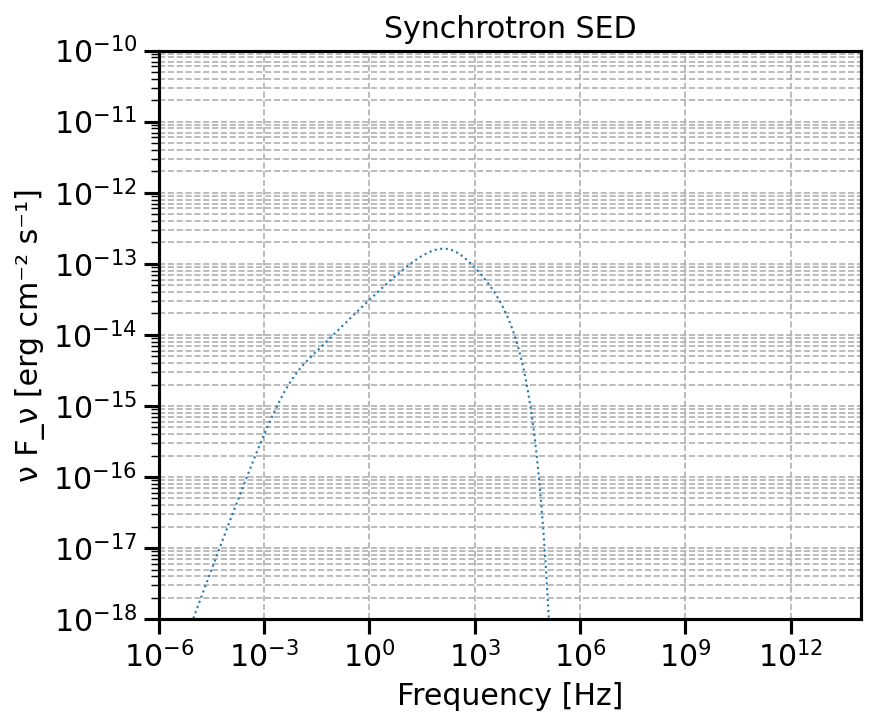

In [78]:
# Plot SED
plt.figure(figsize=(6,5))
plt.loglog(nu_obs.to('eV',equivalencies=u.spectral()), jet.norm_equi*sed_nossa_1, linestyle='dotted',lw=1)
plt.xlabel("Frequency [Hz]")
plt.ylabel("ν F_ν [erg cm⁻² s⁻¹]")
plt.title("Synchrotron SED")
plt.grid(True, which='both', ls='--')
plt.ylim(1e-18, 1e-10)
plt.xlim(1e-6,1e14)
plt.tight_layout()
plt.show()

In [21]:
gamma = np.logspace(3,7,500)

/var/folders/6l/rfzttlkj3rgb82b10q8sd89m0000gn/T/ipykernel_4315/3349388503.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/var/folders/6l/rfzttlkj3rgb82b10q8sd89m0000gn/T/ipykernel_4315/3349388503.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


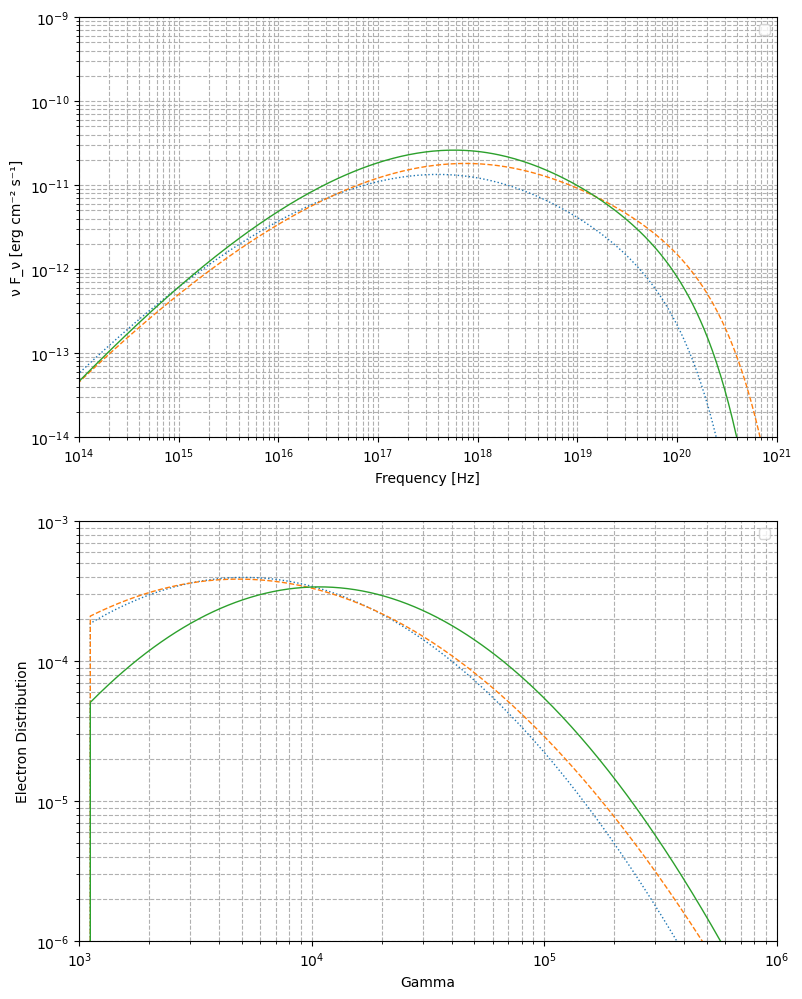

In [22]:
fig, axes = plt.subplots(2,1, figsize=(9, 12))

axes[0].loglog(nu_obs, sed_nossa_1, linestyle='dotted',lw=1)
axes[0].loglog(nu_obs, sed_nossa_2, linestyle='dashed',lw=1)
axes[0].loglog(nu_obs, sed_nossa_3, linestyle='solid',lw=1)
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_ylabel("ν F_ν [erg cm⁻² s⁻¹]")
axes[0].grid(True, which='both', ls='--')
axes[0].set_ylim(1e-14, 1e-9)
axes[0].set_xlim(1e14, 1e21)
axes[0].legend()

axes[1].loglog(gamma, n_1(gamma), linestyle='dotted',lw=1)
axes[1].loglog(gamma, n_2(gamma), linestyle='dashed',lw=1)
axes[1].loglog(gamma, n_3(gamma), linestyle='solid',lw=1)
axes[1].set_xlabel("Gamma")
axes[1].set_ylabel("Electron Distribution")
axes[1].grid(True, which='both', ls='--')
axes[1].set_ylim(1e-6,1e-3)
axes[1].set_xlim(1e3,1e6)
axes[1].legend()


- Mrk 421

In [ ]:
mrk421_2011= Table.read(
    "/Users/usharma/Documents/GitHub/agnpy/agnpy/data/mwl_seds/Mrk421_2011.ecsv",
    format="ascii.ecsv")
mrk421_2011['e_ref'] = mrk421_2011['e_ref'].to('Hz',equivalencies=u.spectral())

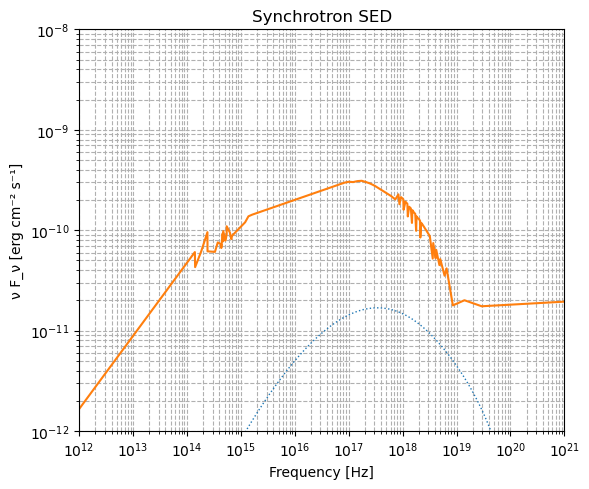

In [104]:
# Plot SED
plt.figure(figsize=(6,5))
plt.loglog(nu_obs, sed_nossa, linestyle='dotted',lw=1)
plt.loglog(mrk421_2011['e_ref'],mrk421_2011['e2dnde'])
plt.xlabel("Frequency [Hz]")
plt.ylabel("ν F_ν [erg cm⁻² s⁻¹]")
plt.title("Synchrotron SED")
plt.grid(True, which='both', ls='--')
plt.ylim(1e-12, 1e-8)
plt.xlim(1e12,1e21)
plt.tight_layout()
plt.show()